In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from transformers import BertTokenizer, BertModel
import nltk
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm import tqdm
from PIL import Image

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
os.makedirs("results", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 40

data = []
with open('captions.txt') as f:
  next(f)
  for line in f:
    img, cap = line.strip().split(',', 1)
    data.append((img,cap.lower()))

all_imgs = sorted(set(img for img, _ in data))
train_imgs, test_imgs = train_test_split(all_imgs, test_size=0.2, random_state=42)
train_imgs, test_imgs = set(train_imgs), set(test_imgs)

train_data = [(i, c) for i, c in data if i in train_imgs]
test_data = [(i, c) for i, c in data if i in test_imgs]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class ImageTextDataset(Dataset):
    def __init__(self, image_dir, data, transform, max_len=40):
        self.image_dir, self.data, self.transform, self.max_len = image_dir, data, transform, max_len

    def encode(self, caption):
        enc = tokenizer(caption, padding="max_length", truncation=True,
                        max_length=self.max_len, return_tensors="pt")
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        image = Image.open(os.path.join(self.image_dir, img_name)).convert("RGB")
        input_ids, attn_mask = self.encode(caption)
        return self.transform(image), input_ids, attn_mask, caption, img_name

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageTextDataset("Images", train_data, transform)
test_dataset  = ImageTextDataset("Images", test_data, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [6]:
class ImageEncoder(nn.Module):
    def __init__(self, EMBED_DIM):
        super().__init__()
        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.fc = nn.Linear(512, EMBED_DIM)

    def forward(self, x):
        return F.normalize(self.fc(self.features(x).flatten(1)), dim=1)

class TextEncoder(nn.Module):
    def __init__(self, EMBED_DIM):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for param in self.bert.parameters():
            param.requires_grad = False
        self.gru = nn.GRU(768, EMBED_DIM, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(EMBED_DIM * 2, 1)
        self.fc = nn.Linear(EMBED_DIM * 2, EMBED_DIM)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        outputs, _ = self.gru(bert_out.last_hidden_state)
        attn_weights = torch.softmax(self.attn(outputs), dim=1)
        context = (attn_weights * outputs).sum(dim=1)
        return F.normalize(self.fc(context), dim=1)

def contrastive_loss(img_emb, txt_emb, temperature=0.07):
    logits = img_emb @ txt_emb.T / temperature
    labels = torch.arange(len(logits), device=logits.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch 8 Loss = 0.1567


Epoch 9: 100%|██████████| 1012/1012 [03:39<00:00,  4.61it/s]


Epoch 9 Loss = 0.1451


Epoch 10: 100%|██████████| 1012/1012 [03:37<00:00,  4.66it/s]


Epoch 10 Loss = 0.1311


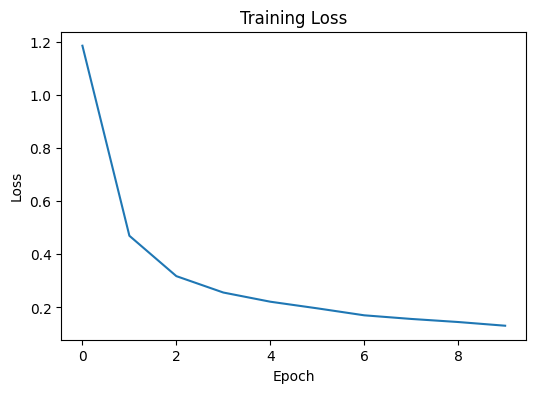

In [7]:
EMBED_DIM = 256
image_encoder = ImageEncoder(EMBED_DIM).to(device)
text_encoder = TextEncoder(EMBED_DIM).to(device)

optimizer = torch.optim.Adam(
    list(image_encoder.parameters()) + list(text_encoder.parameters()), lr=1e-4
)

train_losses = []
for epoch in range(10):
    image_encoder.train()
    text_encoder.train()
    total_loss = 0
    for imgs, input_ids, attn_mask, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
      imgs = imgs.to(device)
      input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
      optimizer.zero_grad()
      loss = contrastive_loss(image_encoder(imgs), text_encoder(input_ids, attn_mask))
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    epoch_loss=total_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1} Loss = {epoch_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.savefig("results/04_loss_curve.png")
plt.show()

In [8]:
torch.save({
    "image_encoder": image_encoder.state_dict(),
    "text_encoder": text_encoder.state_dict(),
    "optimizer": optimizer.state_dict(),
    "epoch_completed": len(train_losses),
    "train_losses": train_losses,
    "config": {
        "embed_dim": EMBED_DIM,
        "lr": 1e-4,
        "batch_size": 32,
        "max_len": 40,
        "total_epochs": 10
    }
}, "checkpoints/04_resnet18_bigru_bert.pth")

In [ ]:
image_encoder.eval()
text_encoder.eval()
all_img_embs, all_txt_embs, all_caps, all_img_names = [], [], [], []

with torch.no_grad():
    for imgs, input_ids, attn_mask, cap_text, img_names in test_loader:
        all_img_embs.append(image_encoder(imgs.to(device)))
        all_txt_embs.append(text_encoder(input_ids.to(device), attn_mask.to(device)))
        all_caps.extend(cap_text)
        all_img_names.extend(img_names)

all_img_embs = torch.cat(all_img_embs)
all_txt_embs = torch.cat(all_txt_embs)

unique_img_names, unique_img_embs = [], []
with torch.no_grad():
    for img_name in sorted(set(all_img_names)):
        img = Image.open(f"Images/{img_name}").convert("RGB")
        emb = image_encoder(transform(img).unsqueeze(0).to(device))
        unique_img_names.append(img_name)
        unique_img_embs.append(emb)
unique_img_embs = torch.cat(unique_img_embs)

In [10]:
def recall_image_to_text(uniq_embs, txt_embs, uniq_names, all_img_names, k=5):
    correct = sum(
        any(all_img_names[j] == uniq_names[i] for j in (uniq_embs[i] @ txt_embs.T).topk(k).indices)
        for i in range(len(uniq_embs))
    )
    return correct / len(uniq_embs)

def recall_text_to_image(txt_embs, uniq_embs, uniq_names, all_img_names, k=5):
    correct = sum(
        any(uniq_names[j] == all_img_names[i] for j in (txt_embs[i] @ uniq_embs.T).topk(k).indices)
        for i in range(len(txt_embs))
    )
    return correct / len(txt_embs)

for k in [1, 5, 10]:
    print(f"Image→Text R@{k}: {recall_image_to_text(unique_img_embs, all_txt_embs, unique_img_names, all_img_names, k):.4f}")
for k in [1, 5, 10]:
    print(f"Text→Image R@{k}: {recall_text_to_image(all_txt_embs, unique_img_embs, unique_img_names, all_img_names, k):.4f}")

Image→Text R@1: 0.1507
Image→Text R@5: 0.3589
Image→Text R@10: 0.4775
Text→Image R@1: 0.1211
Text→Image R@5: 0.3323
Text→Image R@10: 0.4621


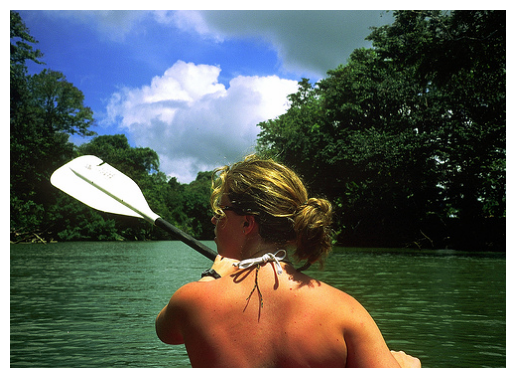

Top captions:
- girl holding a net and walking in a lake at sunset
- a person with a fishing pole is backlit against a blue cloudy sky .
- two people standing in tree on a sunny day
- a person swimming in a pretty lake with a waterfall in the background
- a person with a fishing pole silhouetted in front of a blue sky .
- two girls looking out over a lake towards a man fishing .
- two people sitting on grass in front of a lake looking at the sky .
- a child in a pool wearing water-wings .
- a person holding a net is standing in the water .
- woman swinging above water while holding a vine .
- a young girl sitting in the grass near a lake .
- a hiker standing on the shore of a lake .
- a small child in water with a splash encircling him while the white clouds float over the mountains .
- a shirtless man standing on the edge of a stream .
- two people having a picnic by a lake .
- a person is standing in shallow water with a fishing net as the sun goes down .
- two people are in a pond p

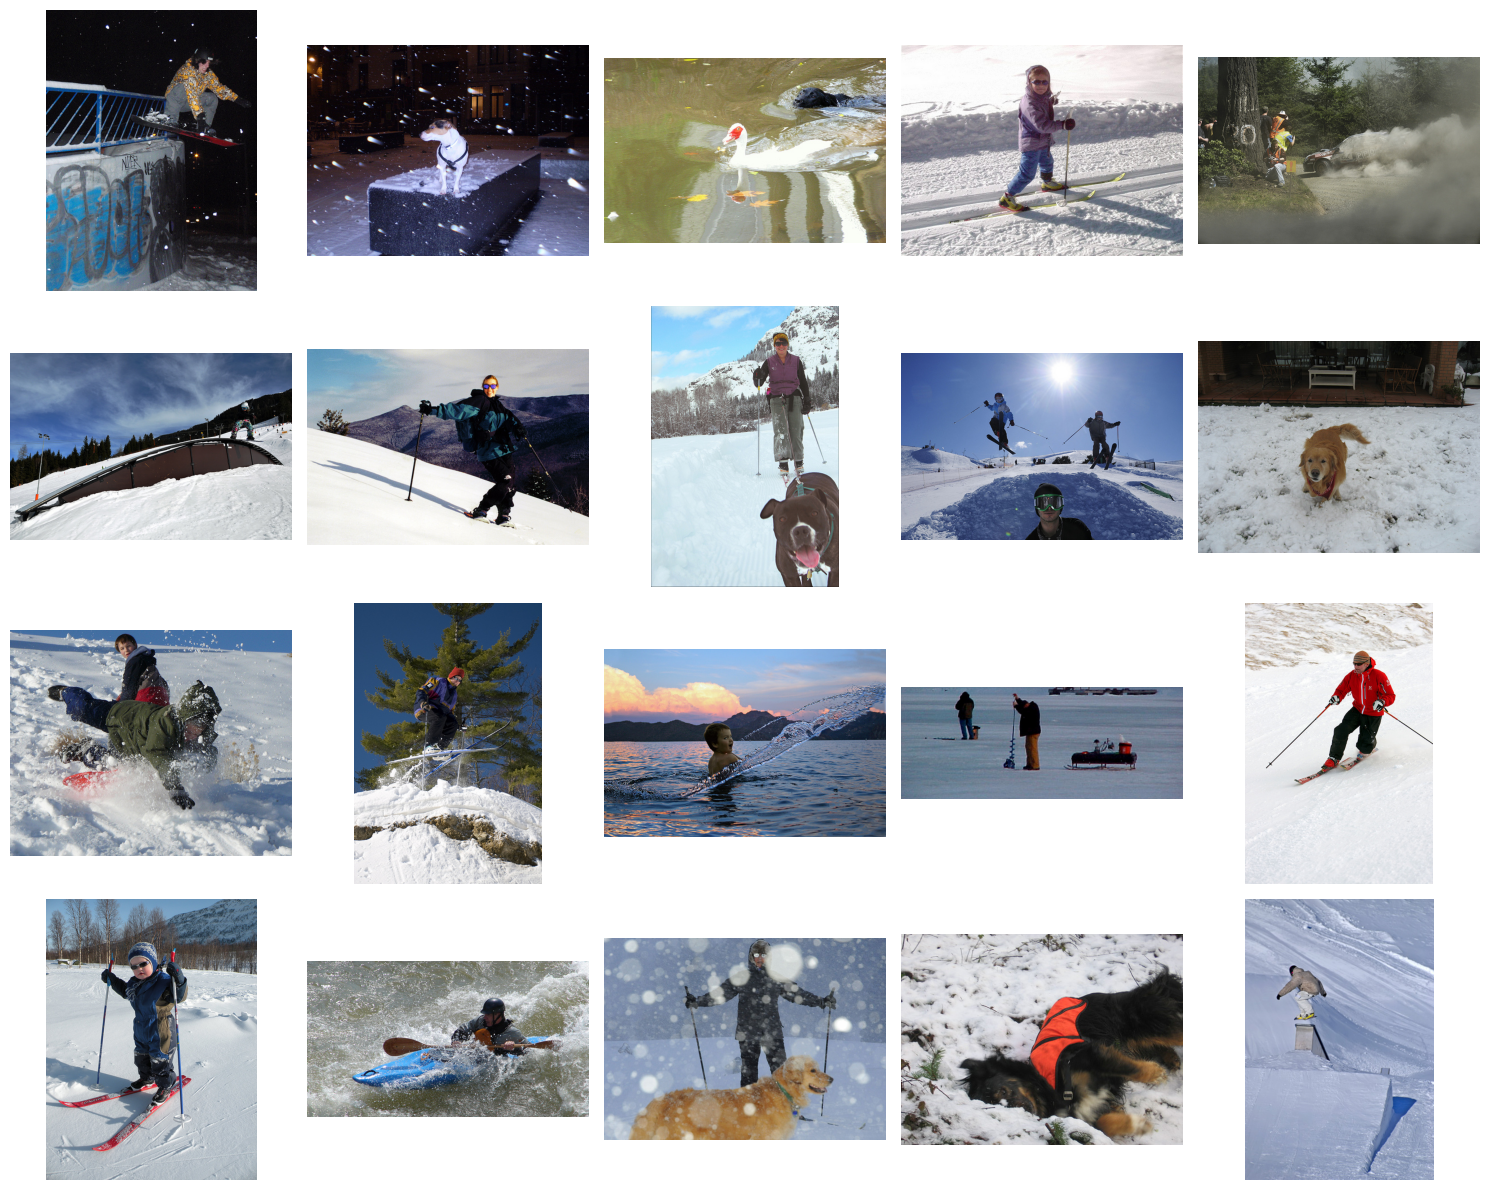

In [ ]:
def show_image_to_text(image_idx, top_k=5):
    topk = (unique_img_embs[image_idx] @ all_txt_embs.T).topk(top_k).indices
    plt.imshow(Image.open(f"Images/{unique_img_names[image_idx]}"))
    plt.axis("off")
    plt.show()
    print("Top captions:"); [print("-", all_caps[i]) for i in topk]

def show_text_to_image(caption_idx, top_k=20, imgs_per_row=5):
    topk = (all_txt_embs[caption_idx] @ unique_img_embs.T).topk(top_k).indices
    print("Query:", all_caps[caption_idx])

    rows = (top_k + imgs_per_row - 1) // imgs_per_row
    plt.figure(figsize=(imgs_per_row * 3, rows * 3))

    for i, idx in enumerate(topk):
        plt.subplot(rows, imgs_per_row, i + 1)
        plt.imshow(Image.open(f"Images/{unique_img_names[idx]}"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_image_to_text(6, top_k=20)
show_text_to_image(6, top_k=20)

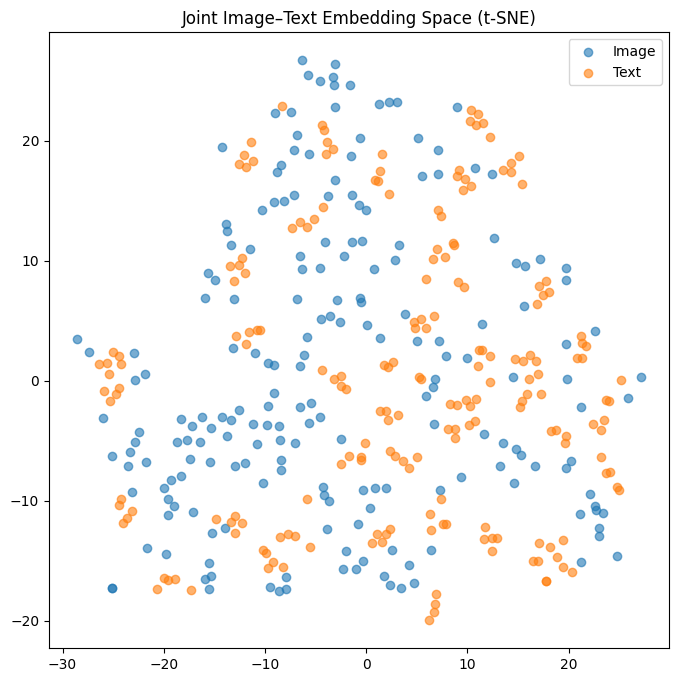

In [12]:
n = min(200, len(unique_img_embs), len(all_txt_embs))
X = np.vstack([unique_img_embs[:n].cpu().numpy(), all_txt_embs[:n].cpu().numpy()])
labels = ["Image"] * n + ["Text"] * n
X_2d = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42).fit_transform(X)

plt.figure(figsize=(8, 8))
for lab in ["Image", "Text"]:
    idx = [i for i, l in enumerate(labels) if l == lab]
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], label=lab, alpha=0.6)
plt.legend()
plt.title("Joint Image–Text Embedding Space (t-SNE)")
plt.savefig("results/04_tsne.png")
plt.show()